### Exercise 7. Poroelastic Sphere

The goal of this exercise is to develop a fully-coupled poroelastic code capable of developing fluid pressure and deformations at the same time

In [1]:
# importing the necessary python modules
# numpy and matplotlib are popular packages for scientific computing and plotting
import numpy as np
import matplotlib.pyplot as plt
import pygmsh

# interactive python (iPython) magic to instruct jupyter how to show the plots with respect to the code cells
%matplotlib inline

# scipy is an extension for numpy, used extensively in scientific computing
import scipy as sp

# various plotting parameters
plt.rcParams['text.usetex'] = False
plt.rcParams['axes.labelsize'] = 12

# The following lines are though to import the source functions
import sys
sys.path.append('../src')

# And we import the necessary tools from our source folder.
from MesherWrapper import Mesh
from MeshUtils import MeshUtils
#import MatrixAssembly
import PoroElasticProperties as prop

### Drainage of a poroelastic sphere

The isotropic compression of a poroelastic sphere of homogeneous medium is also called Cryer's sphere. We will compute a numerical solution of the displacement and pressure at every point in the sphere after application of a mechanical load with an initial stress field.

We will start by defining the mesh. Taking advantage of the problem's radial symmetry, we can reduce the domain to a quarter circle and then run axissymetric simmulation.

In [2]:
# we define the mesh by drawing a quarter cirle of a radius 1.
# important to mention that the closed loop should have nodes called in counter-clockwise direction
r = 1
cell_size = 0.05

import pygmsh
with pygmsh.geo.Geometry() as geom:
    center_point = geom.add_point([0, 0], cell_size)
    top_point = geom.add_point([0, r], cell_size)
    right_point = geom.add_point([r, 0], cell_size)

    left_nodes = geom.add_line(center_point, top_point)
    bottom_nodes = geom.add_line(right_point, center_point)
    arc = geom.add_circle_arc(top_point, center_point, right_point)

    loop = geom.add_curve_loop([-left_nodes, -bottom_nodes, -arc])
    surface = geom.add_plane_surface(loop)
    out = geom.generate_mesh()

mesh = Mesh(out, simultype='axis')
mesh = MeshUtils.tri3_to_tri6(mesh)
mesh.plot()
plt.xlabel('x')
plt.ylabel('y')
print(mesh.number_nodes)
print(mesh.nodes.shape)


ValueError: all the input array dimensions except for the concatenation axis must match exactly, but along dimension 0, the array at index 0 has size 762 and the array at index 1 has size 1

In [3]:
# geomechanical parameters
k = 8.4e3  # elastic drained bulk modulus [MPa]
g = 6.8e3  # shear modulus [MPa]
b = 0.707692  # biot coefficient
M = 9.18478e3  # biot modulus [MPa]
k_u = k + M*b**2
perm = 0.137549e-3  # permeability
mu_f = 1  # fluid viscosity
rho = 1  # density
kappa = perm / mu_f  # conductivity
nu_u = prop.poisson_ratio(g, k_u)  # undrained Poisson ratio
E_u = prop.young_modulus(g, k_u)  # undrained Young modulus
nu = prop.poisson_ratio(g, k)  # Poisson ratio
E = prop.young_modulus(g, k)  # Young modulus

### Boundary conditions

We will impose that there are no radial displacements on the left boundary and no vertical displacements on the bottom boundary.

Additionally, the pressure on the outer boundary (circle) will be fixed in the later stages. Here, we will only detect the nodes laying on the external surface of the sphere.

Note that it will be necessary to introduce a rounding as to realy capture all the points. This is because we need to account
for the numerical imprecision of the meshing.

In [ ]:
# detecting nodes belonging to the left and bottom lines
# complete the code below
# left_line = 
# bottom_line

# numbering the corresponding degrees of freedom
fixed_dofx = left_nodes * 2
fixed_dofy = bottom_nodes * 2 + 1

# grouping fixed nodes and fixed dofs and getting rid of duplicates
# complete the code below
# fixed_nodes = 
# fixed_dof = 

# detecting nodes at the external surface of the sphere
# complete the code below
# surface_nodes = 

mesh.plot()
plt.scatter(*mesh.nodes[surface_nodes].T, zorder=10)
plt.scatter(*mesh.nodes[fixed_nodes].T, zorder=10)

### Defining an initial stress field

As an initial condition we will set a unifrom hydrostatic stress field with values equal to -1 (compression). Note that it would also be possible
to define the initial state by a traction applied on the boundary which results in the same final result.
The stress vector in axissymmetry is defined as

$$ \sigma = \left(\sigma_{rr}\ \sigma_{zz}\ \tau_{rz}\ \sigma_{\theta \theta}\right)^\intercal.$$

We will apply an isotropic stress field of unity with the ``set_stress_field`` function. This outputs a vector of internal forces of length ``2 * mesh.nn``, giving the two components of internal force at each node. 

Within the bulk and on the free boundaries (natural Neumann BC), vector of internal forces has to be zero for a static body. This happens because of forces originating from neighboring elements are equilibrating at a node. At the Dirichlet boundaries, the internal forces vector is not zero and it equals to the reaction force.

In [4]:
import MatrixAssembly

(<Figure size 640x480 with 2 Axes>,
 <Axes: >,
 <matplotlib.colorbar.Colorbar at 0x120854190>)

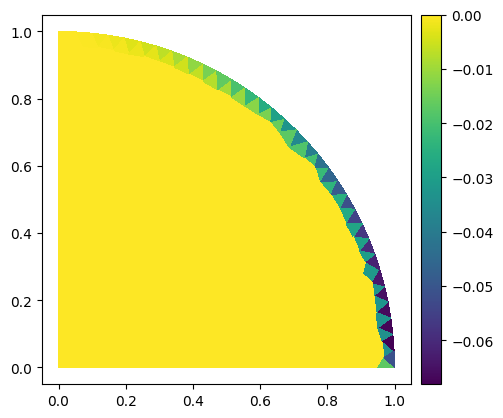

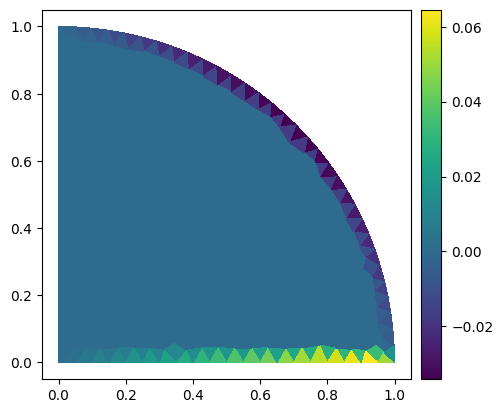

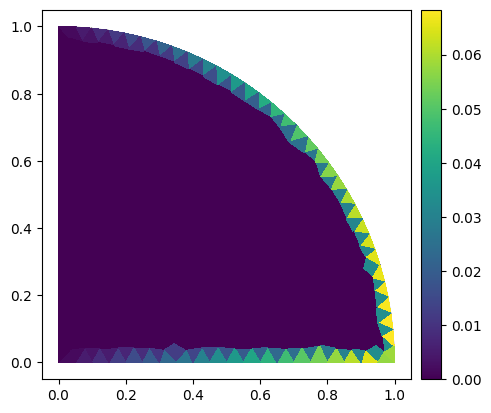

In [7]:

# initial stress field
sig_unif = [-1, -1, 0, -1]
int_force_0 = MatrixAssembly.set_stress_field(mesh, sig_unif)

# let's plot the internal forces field
# we can reshape the int_force_0 vector to a shape (2, mesh.number_nodes)
s0 = int_force_0.reshape(2, -1, order='F')
mesh.plot(s0[0], c='none', shading='flat')
mesh.plot(s0[1], c='none', shading='flat')
mesh.plot(np.linalg.norm(s0, axis=0), c='gray', shading='flat')


### Matrix assembly
In the previous exercises, we have coded up the conductivity matrix $\mathbf{C}$, the mass matric $\mathbf{M}$ and the stiffness matrix $\mathbf{K}$. Now, to fully couple porous flow and elasticity, we need to assemble the *coupling* matrix $\mathbf{A}$. You need to complete the function assemble_coupling_matrix() in MatrixAssembly


In [5]:
import MatrixAssembly as ma
# assembling the different matrices
K = ma.assemble_stiffness_matrix(mesh, E, nu)
S = ma.assemble_mass_matrix(mesh, 1/M)
C = ma.assemble_conductivity_matrix(mesh, kappa)

# you need to complement the function below in its corresponding class MatrixAssembly
A = ma.assemble_coupling_matrix(mesh, b)

### Undrained conditions

The solution at $t=0$ corresponds to the undrained conditions. We will need to assemble the full matrix $\mathbf{T}$, containing the previously defined matrices. At this step, the pressure on the sphere surface is not.

In [ ]:
# we can now solve the undrained case
dt = 0.
# bottom right part of the full matrix
SC = S + dt *C

# getting number of degrees of freedom for each subproblem
ntot_E = K.shape[0]
ntot_P = S.shape[0]
ntot = ntot_E + ntot_P

# assembling the full matrix
# complete the code below
# top = sp.sparse.hstack((..., ...), format='csc')
# bottom = sp.sparse.hstack((..., ...), format='csc')

T = sp.sparse.csc_matrix(sp.sparse.vstack((top, bottom)), format='csc')

# setting the force vector to the initial conditions
Ftot = np.zeros(ntot)
Ftot[:ntot_E] = int_force_0

# getting the numbers of free degrees of freedom
eq_free_disp = np.setdiff1d(np.arange(ntot_E), fixed_dof)
eq_free_p = np.arange(ntot_P) + ntot_E
eq_free = np.hstack((eq_free_disp, eq_free_p))


In [ ]:
# solving the system
undrained_sol = np.zeros(ntot)
undrained_sol[eq_free] = np.linalg.solve(T[eq_free][:, eq_free], Ftot[eq_free])

# undrained sol has the shape (2 * mesh.nn + mesh.nn, 1), corresponding to the x and y displacements and the pressure.
# we can reshape this vector to access the pressure and displaements easily

# complete the code below:
# pressure_undrained = 
# disp_undrained = 

In [ ]:
%matplotlib inline
fig, ax, cb = mesh.plot(pressure_undrained, shading='flat')
ax.set_title('pressure', loc='left')

fig, ax, cb = mesh.plot(disp_undrained[0])
ax.set_title('$u_x$ (m)', loc='left')

fig, ax, cb = mesh.plot(disp_undrained[1])
ax.set_title('$u_y$ (m)', loc='left')

factor = 1000
fig, ax, cb = mesh.plot(factor * np.linalg.norm(disp_undrained, axis=0), c='k')
ax.triplot(*(mesh.nodes.T + factor * disp_undrained), c='tab:red', lw=0.5)
ax.set_title(f'displacement (m) ({factor} x multiplication) ', loc='left')

### Solving the drained response for $t > 0$

Using a constant time step, we can now:

- assemble a full matrix where $\Delta t$ is not zero and
- set the pressure at the outer boundary to be fixed at zero.

We will use the previously seen scheme to solve the time derivatives between $t=0$ and $t=1$.

In [ ]:
# set up a time step
dt = 0.005
# build a vector of time linearly increasing from 0 to 1 with the given timestep
# complete the code below
# t = 

# reassemble the bottom right part of the full matrix
# complete the code below:
# SC =

# update the corresponding part of the full matrix
# complete the code below:
# bottom =
T = sp.sparse.vstack((top, bottom), format='csc')

# create empty arrays for pressure and displacement having number of timesteps as the number of rows
# complete the code below:
# pressure = 
# displacement = 

# create a copy of undrained solution and use it as a previous step solution
sol = undrained_sol.copy()
# fix the pressure to zero on the surface 
# [+ ntot_E] is displacing the pressure DOFs within the vector of unknowns
sol[surface_nodes + ntot_E] = 0

# redefining the free degrees of freedom (as it changes in pressure)
eq_free_disp = np.setdiff1d(np.arange(ntot_E), fixed_dof)
eq_free_p = np.setdiff1d(np.arange(ntot_P), surface_nodes) + ntot_E
eq_free = np.hstack((eq_free_disp, eq_free_p))

# call to superLU to get the LU factorization of the matrix 
# valid when the time-step is kept constant.
# complete below
# Tinv = sp.sparse.linalg.splu(T[...][...]) 

# time loop 
rhs = np.zeros(ntot)
for i in range(len(t)):
    print(f'\ time step # {i+1} out of {len(t)}', end='\n')

    # calculate the change in nodal flux (scalar)
    rhs[eq_free_p] = dt * C[eq_free_p - ntot_E].dot(sol[ntot_E:])

    # solve the system for the increment
    # complete the code below
    # delta_x = 

    # update the solution
    # complete the code below
    # sol[...] 

    # fill in corresponding rows of pressure and displacement arrays
    # complete the code below
    # pressure[...] = 
    # displacement[...] = 

### Comparison with an analytical solution
The analytical solution is contained in the file ``PP-Sphere-ohio.csv`` and shows the pressure at the center of our poroelastic sphere. We will need to extract the nodes at this location. We can also look at the displacements at the outer boundary of the sphere (and only one point is needed because of the symmetry).

In [ ]:
top_point = np.argwhere((mesh.nodes[:, 0] <= 1e-3) & (np.abs(mesh.nodes[:, 1] - r) <= 1e-3))[:, 0]
center_point = np.argwhere((mesh.nodes[:, 0] <= 1e-3) & (mesh.nodes[:, 1] <= 1e-3))[:, 0]
right = np.argwhere((mesh.nodes[:, 1] <= 1e-3) & (np.abs(mesh.nodes[:, 0] - r) <= 1e-3))[:, 0]

mesh.plot()
plt.scatter(*mesh.nodes[top_point].T)
plt.scatter(*mesh.nodes[right].T)
plt.scatter(*mesh.nodes[center_point].T)


In [ ]:
%matplotlib inline
analt, analp = np.loadtxt('PP-Sphere-ohio.csv', delimiter=',').T
plt.plot(analt, analp, label='analytical solution', c='k')
plt.plot(t, pressure[:, center_point], lw=0, marker='.', ms=10, markevery=0.05, label='numerical solution', c='tab:red')

plt.legend(frameon=False)
plt.xlabel('t (s)')
plt.ylabel('pressure (m)')
plt.xlim(0, 1)

In [ ]:
# we can also look at the displacementes at the boundary
# however here we have no analytical solution to compare with
norm = np.linalg.norm(displacement, axis=1)
plt.plot(t, norm[:, top_point], label='top')
plt.plot(t, norm[:, right], label='right')
plt.legend(title='total displacement', frameon=False)
plt.xlabel('t (s)')
plt.ylabel('displacement (m)')